In [1]:
# প্রয়োজনীয় Library গুলো Import করে নিচ্ছি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_regression, make_classification

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (7, 5)

print("সব Library Successfully Import হয়ে গেছে!")

সব Library Successfully Import হয়ে গেছে!


# Set Up
**Dataset Loading**
**Data type checking**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/fairuzahmedfza/house-price/housing.csv')

In [3]:
print(f'The shape of the dataset is {df.shape}')
print(f"Checking the column names and data types \n{df.dtypes}")
print(f"Checking the column names and data types \n{df.info()}")

print(f'The head is \n{df.head(10)}')
print(f"The tail is \n{df.tail(10)}")

The shape of the dataset is (20640, 10)
Checking the column names and data types 
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   

# Exploratory Data Analysis (EDA)

# Univariate Analysis

**Histogram for every numeric column**

/tmp/ipykernel_58/548334998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ocean_proximity', ax=axes[0,0], palette=['blue', 'red'])
/tmp/ipykernel_58/548334998.py:4: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x='ocean_proximity', ax=axes[0,0], palette=['blue', 'red'])


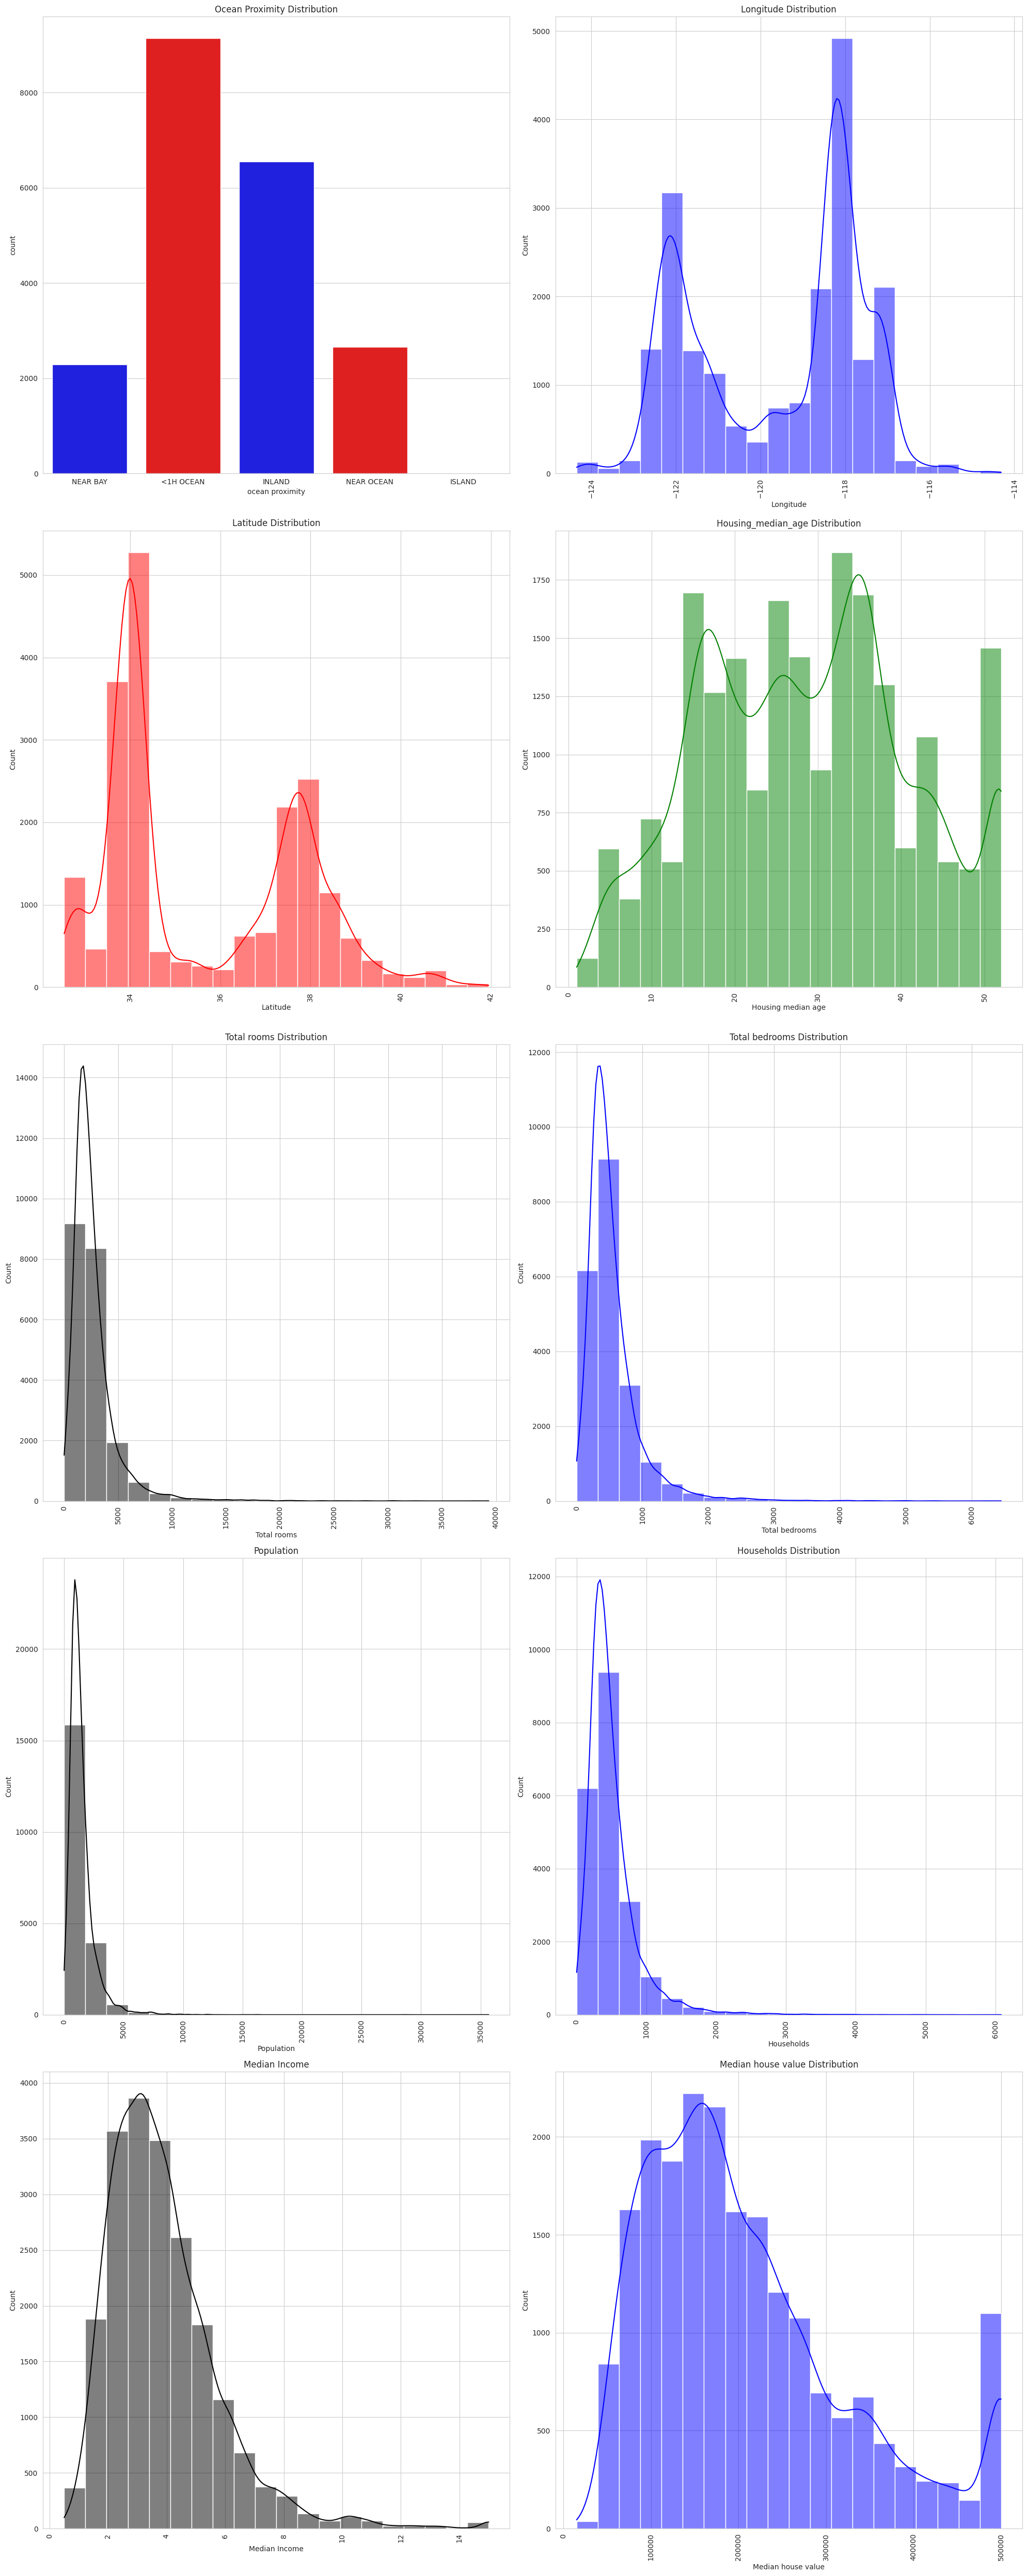

In [4]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(5, 2, figsize=(20, 50))
# 1. Ocean proximity count Plot
sns.countplot(data=df, x='ocean_proximity', ax=axes[0,0], palette=['blue', 'red'])
axes[0,0].set_title('Ocean Proximity Distribution')
axes[0,0].set_xlabel('ocean proximity')

# 2. longitude Histogram Plot
sns.histplot(data=df, x='longitude', ax=axes[0,1], bins=20, kde=True, color='blue')
axes[0,1].set_title('Longitude Distribution')
axes[0,1].set_xlabel('Longitude')
axes[0,1].tick_params(axis='x', rotation=90)

# 3. latitude Histogram Plot
sns.histplot(data=df, x='latitude', ax=axes[1,0], bins=20, kde=True, color='red')
axes[1,0].set_title('Latitude Distribution')
axes[1,0].set_xlabel('Latitude')
axes[1,0].tick_params(axis='x', rotation=90)

# 4. housing_median_age Histogram Plot
sns.histplot(data=df, x='housing_median_age', ax=axes[1,1], bins=20, kde=True, color='green')
axes[1,1].set_title('Housing_median_age Distribution')
axes[1,1].set_xlabel('Housing median age')
axes[1,1].tick_params(axis='x', rotation=90)


# 5. total_rooms Histogram Plot
sns.histplot(data=df, x='total_rooms', ax=axes[2,0], bins=20, kde=True, color='black')
axes[2,0].set_title('Total rooms Distribution')
axes[2,0].set_xlabel('Total rooms')
axes[2,0].tick_params(axis='x', rotation=90)


# 6. total_bedrooms Histogram Plot
sns.histplot(data=df, x='total_bedrooms', ax=axes[2,1], bins=20, kde=True, color='blue')
axes[2,1].set_title('Total bedrooms Distribution')
axes[2,1].set_xlabel('Total bedrooms')
axes[2,1].tick_params(axis='x', rotation=90)

# 7. population Histogram Plot
sns.histplot(data=df, x='population', ax=axes[3,0], bins=20, kde=True, color='black')
axes[3,0].set_title('Population')
axes[3,0].set_xlabel('Population')
axes[3,0].tick_params(axis='x', rotation=90)

# 8. Households Histogram Plot
sns.histplot(data=df, x='households', ax=axes[3,1], bins=20, kde=True, color='blue')
axes[3,1].set_title('Households Distribution')
axes[3,1].set_xlabel('Households')
axes[3,1].tick_params(axis='x', rotation=90)

# 9. Median Income Histogram Plot
sns.histplot(data=df, x='median_income', ax=axes[4,0], bins=20, kde=True, color='black')
axes[4,0].set_title('Median Income')
axes[4,0].set_xlabel('Median Income')
axes[4,0].tick_params(axis='x', rotation=90)

# 10. Median House Value Histogram Plot
sns.histplot(data=df, x='median_house_value', ax=axes[4,1], bins=20, kde=True, color='blue')
axes[4,1].set_title('Median house value Distribution')
axes[4,1].set_xlabel('Median house value')
axes[4,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

**Plot a geographic scatter plot of longitude vs. latitude, colored by median_house_value.**

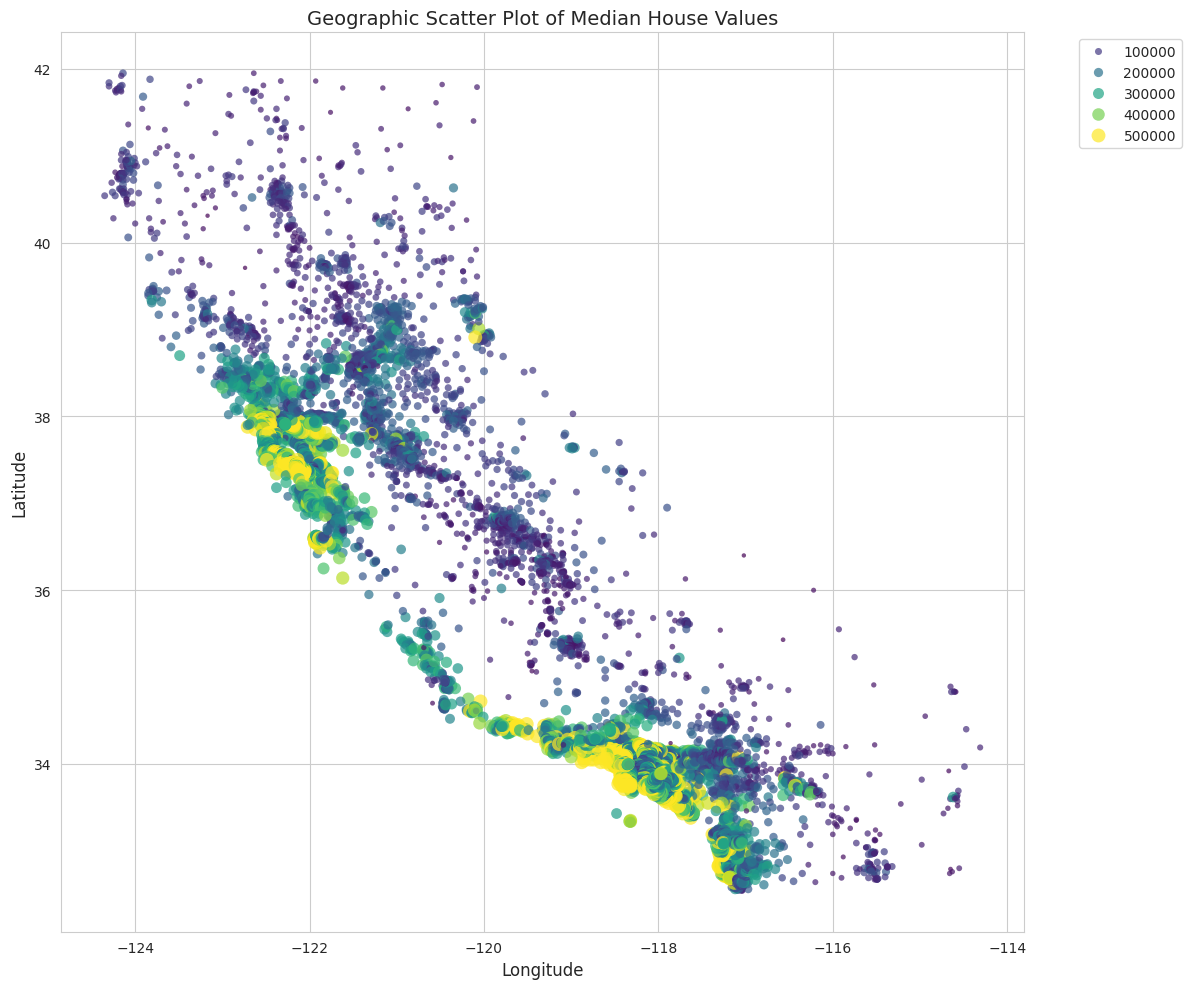

In [5]:
plt.figure(figsize=(12, 10))
scatter = sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='median_house_value',
    palette='viridis',
    size='median_house_value',
    sizes=(10, 100),
    alpha=0.7,
    edgecolor='none'
)

plt.title('Geographic Scatter Plot of Median House Values', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Bivariate Analysis 

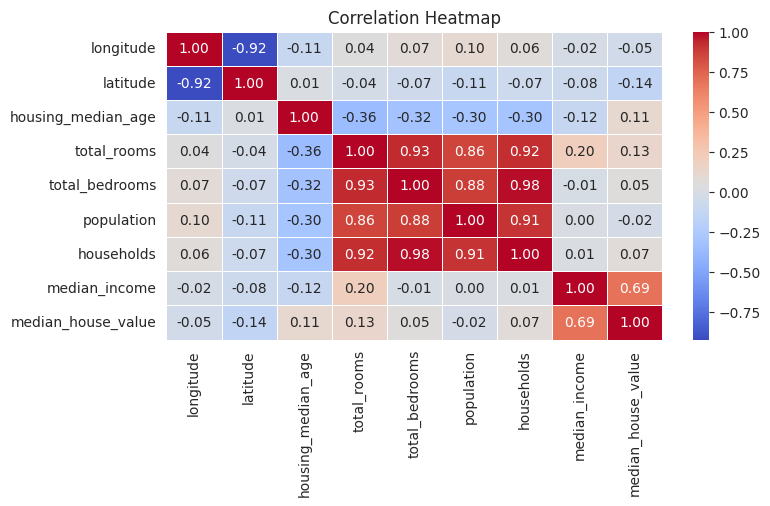

In [6]:
dataframe = pd.DataFrame(df, columns=['longitude', 'latitude', 'housing_median_age', 
                                      'total_rooms', 'total_bedrooms', 'population',
                                      'households','median_income', 'median_house_value'])
matrix = dataframe.corr()
plt.figure(figsize=(8,4))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Missing Value, Duplicate Row and Data Basic Statistics (.describe())**

In [7]:
#Checking basic statistics of the dataset
print(f'\nChecking basic statistics of the dataset: \n{df.describe()}')
#Missing values
print(f"Printing the number of missing values per column \n{df.isnull().sum()}")
print(f"Printing the percentage of missing values per column \n{df.isnull().mean()*100}")
#Duplicate rows
print(f'\nPrinting the number of duplicate rows: {df.duplicated().sum()}')


Checking basic statistics of the dataset: 
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.0

**Filling Missing values with the SimpleImputer(constant value)**

In [8]:
const = df['total_bedrooms'].mean()/df['total_rooms'].mean()
const = np.floor(const * df['total_rooms'])
print(f"Constant: {const}")
# imputer = SimpleImputer(strategy='constant',fill_value = const)
# df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])

df['total_bedrooms'] = df['total_bedrooms'].fillna(const)

Constant: 0         179.0
1        1448.0
2         299.0
3         259.0
4         332.0
          ...  
20635     339.0
20636     142.0
20637     459.0
20638     379.0
20639     568.0
Name: total_rooms, Length: 20640, dtype: float64


In [9]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [10]:
#Checking basic statistics of the dataset
print(f'\nChecking basic statistics of the dataset: \n{df.describe()}')
#Missing values
print(f"Printing the number of missing values per column \n{df.isnull().sum()}")
print(f"Printing the percentage of missing values per column \n{df.isnull().mean()*100}")


Checking basic statistics of the dataset: 
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20640.000000  20640.000000  20640.000000   20640.000000   
mean       537.715891   1425.476744    499.539680       3.870671   
std        420.849805   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.0

**Checking ocean proximity value**

In [11]:
print(f"Unique ocean proximity values: {df['ocean_proximity'].unique()}")

Unique ocean proximity values: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']
